# 平均調整 有り/無し × 統合次元の結果を結合・可視化

このノートブックは、`output/平均調整＋統合次元増加` と `output/平均調整なし＋統合次元増加` 内の `result_grid_*.csv` を結合し、列 `inter_normalization` でラベル付けして保存・可視化します。

In [3]:
# 必要ライブラリの読み込み
import os
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Yu Gothic"  # 日本語フォント（環境に合わせて調整）
plt.rcParams["figure.figsize"] = (8, 5)
sns.set(style="whitegrid")

print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)


matplotlib: 3.10.0
seaborn: 0.13.2


In [9]:
# ディレクトリ設定
BASE = Path.cwd() # Path.cwd().parent if Path.cwd().name == "output" else Path.cwd() / "output"
DIR_WITH_MEAN = BASE / "平均調整＋統合次元増加"
DIR_NO_MEAN  = BASE / "平均調整なし＋統合次元増加"

print("DIR_WITH_MEAN:", DIR_WITH_MEAN)
print("DIR_NO_MEAN:", DIR_NO_MEAN)

for p in [DIR_WITH_MEAN, DIR_NO_MEAN]:
    if not p.exists():
        print(f"警告: ディレクトリが見つかりません: {p}")

DIR_WITH_MEAN: c:\Users\sueya\Git-Repositories\takano_labo\dca\output\平均調整＋統合次元増加
DIR_NO_MEAN: c:\Users\sueya\Git-Repositories\takano_labo\dca\output\平均調整なし＋統合次元増加


In [10]:
def _read_csv_safe(path: Path) -> pd.DataFrame:
    for enc in ("utf-8-sig", "utf-8", "cp932"):
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            continue
    return pd.read_csv(path, engine="python", on_bad_lines="skip")


def load_results_with_label(dir_path: Path, label: str) -> pd.DataFrame:
    files = sorted(dir_path.rglob("result_grid_*.csv"))
    dfs = []
    for f in files:
        try:
            df = _read_csv_safe(f)
            df["source_file"] = str(f)
            df["inter_normalization"] = label
            dfs.append(df)
        except Exception as e:
            print(f"[skip] 読み込み失敗: {f} ({e})")
    if not dfs:
        return pd.DataFrame()
    return pd.concat(dfs, ignore_index=True)


df_with = load_results_with_label(DIR_WITH_MEAN, "with_mean_norm")
df_none = load_results_with_label(DIR_NO_MEAN, "without_mean_norm")

df_all = pd.concat([df_with, df_none], ignore_index=True) if not df_with.empty or not df_none.empty else pd.DataFrame()
print("with_mean_norm:", len(df_with), "rows")
print("without_mean_norm:", len(df_none), "rows")
print("total:", len(df_all), "rows")
df_all.head()

with_mean_norm: 140 rows
without_mean_norm: 135 rows
total: 275 rows


,dataset,h_model,F_type,G_type,dim_intermediate,dim_integrate,num_institution_user,anchor_method,loop_num,score_mean,score_stdev,even_ind_mean,odd_ind_mean,ind_mean,mean_mean,even_mean,odd_mean,integ_metrics_mean,source_file,inter_normalization
0,breast_cancer,mlp,svd,nonlinear,3,3,10000000,gaussian,10,0.801829,0.067540,NaN,NaN,NaN,0.8341,0.8341,0.8341,5.8,c:\Users\sueya\Git-Repositories\takano_labo\dc...,with_mean_norm
1,breast_cancer,mlp,svd,nonlinear,3,4,10000000,gaussian,10,0.830117,0.077423,NaN,NaN,NaN,0.7794,0.7794,0.7794,8.3,c:\Users\sueya\Git-Repositories\takano_labo\dc...,with_mean_norm
2,breast_cancer,mlp,svd,nonlinear,3,5,10000000,gaussian,10,0.866265,0.074347,NaN,NaN,NaN,0.9073,0.9073,0.9073,11.2,c:\Users\sueya\Git-Repositories\takano_labo\dc...,with_mean_norm
3,breast_cancer,mlp,svd,nonlinear,3,7,10000000,gaussian,10,0.893020,0.054949,NaN,NaN,NaN,0.9397,0.9397,0.9397,15.1,c:\Users\sueya\Git-Repositories\takano_labo\dc...,with_mean_norm
4,breast_cancer,mlp,svd,Imakura,3,3,10000000,gaussian,10,0.951275,0.025302,NaN,NaN,NaN,0.9822,0.9822,0.9822,24.6,c:\Users\sueya\Git-Repositories\takano_labo\dc...,with_mean_norm


In [13]:
# 集計: score_mean / score_stdev を用意（無ければ計算）
import numpy as np
import pandas as pd

if 'df_all' not in globals() or df_all is None or len(df_all) == 0:
    raise RuntimeError('df_all が空です。上のセルで CSV を結合してから実行してください。')

# 作業用コピー
_df = df_all.copy()

# F_type が無ければ補完
if 'F_type' not in _df.columns:
    _df['F_type'] = 'unknown'

# inter_normalization → bool へ正規化
import numpy as _np

def _to_bool_norm(v):
    if isinstance(v, (bool, _np.bool_)):
        return bool(v)
    if isinstance(v, str):
        s = v.strip().lower()
        if s in ('true','t','yes','y','1','with_mean_norm','with','mean','on','enabled'):
            return True
        if s in ('false','f','no','n','0','without_mean_norm','without','none','off','disabled'):
            return False
    try:
        return bool(int(v))
    except Exception:
        return False

_df['inter_norm_flag'] = _df.get('inter_normalization', False).apply(_to_bool_norm)

# dim_integrate は数値
_df['dim_integrate'] = pd.to_numeric(_df['dim_integrate'], errors='coerce') if 'dim_integrate' in _df.columns else _df.assign(dim_integrate=_np.nan)['dim_integrate']

# スコア列の決定 & 集計
if 'score_mean' in _df.columns and 'score_stdev' in _df.columns:
    _df['score_mean'] = pd.to_numeric(_df['score_mean'], errors='coerce')
    _df['score_stdev'] = pd.to_numeric(_df['score_stdev'], errors='coerce')
    _group_cols = ['dataset','F_type','G_type','inter_norm_flag','dim_integrate']
    for c in _group_cols:
        if c not in _df.columns:
            _df[c] = 'unknown' if c in ('dataset','G_type') else _np.nan
    agg = (_df
           .groupby(_group_cols, dropna=False)
           .agg(score_mean=('score_mean','mean'),
                score_stdev=('score_stdev','mean'),
                n=('score_mean','count'))
           .reset_index())
else:
    base_cols = ['score','auc','losses_mean','評価値']
    base_col = next((c for c in base_cols if c in _df.columns), None)
    if base_col is None:
        raise ValueError('スコア列が見つかりません（score_mean が無い場合は score/auc/評価値 等が必要です）。')
    _df[base_col] = pd.to_numeric(_df[base_col], errors='coerce')
    _group_cols = ['dataset','F_type','G_type','inter_norm_flag','dim_integrate']
    for c in _group_cols:
        if c not in _df.columns:
            _df[c] = 'unknown' if c in ('dataset','G_type') else _np.nan
    agg = (_df
           .groupby(_group_cols, dropna=False)
           .agg(score_mean=(base_col,'mean'),
                score_stdev=(base_col,'std'),
                n=(base_col,'count'))
           .reset_index())

print('agg rows:', len(agg))
agg.head()

agg rows: 275


,dataset,F_type,G_type,inter_norm_flag,dim_integrate,score_mean,score_stdev,n
0,breast_cancer,kernel_pca_self_tuning,GEP,False,3,0.763991,0.061342,1
1,breast_cancer,kernel_pca_self_tuning,GEP,True,3,0.824829,0.064777,1
2,breast_cancer,kernel_pca_self_tuning,Imakura,False,3,0.637137,0.112592,1
3,breast_cancer,kernel_pca_self_tuning,Imakura,True,3,0.789841,0.075737,1
4,breast_cancer,kernel_pca_self_tuning,ODC,False,3,0.509532,0.081276,1


C:\Users\sueya\AppData\Local\Temp\ipykernel_3620\3720306131.py:83: UserWarning: Glyph 12399 (\N{HIRAGANA LETTER HA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sueya\AppData\Local\Temp\ipykernel_3620\3720306131.py:83: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sueya\AppData\Local\Temp\ipykernel_3620\3720306131.py:83: UserWarning: Glyph 32218 (\N{CJK UNIFIED IDEOGRAPH-7DDA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sueya\AppData\Local\Temp\ipykernel_3620\3720306131.py:83: UserWarning: Glyph 12289 (\N{IDEOGRAPHIC COMMA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sueya\AppData\Local\Temp\ipykernel_3620\3720306131.py:83: UserWarning: Glyph 12381 (\N{HIRAGANA LETTER SO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sueya\AppData\Local\Temp\ipykernel_3620\3720306131.py:83: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) Arial.
  plt.tigh

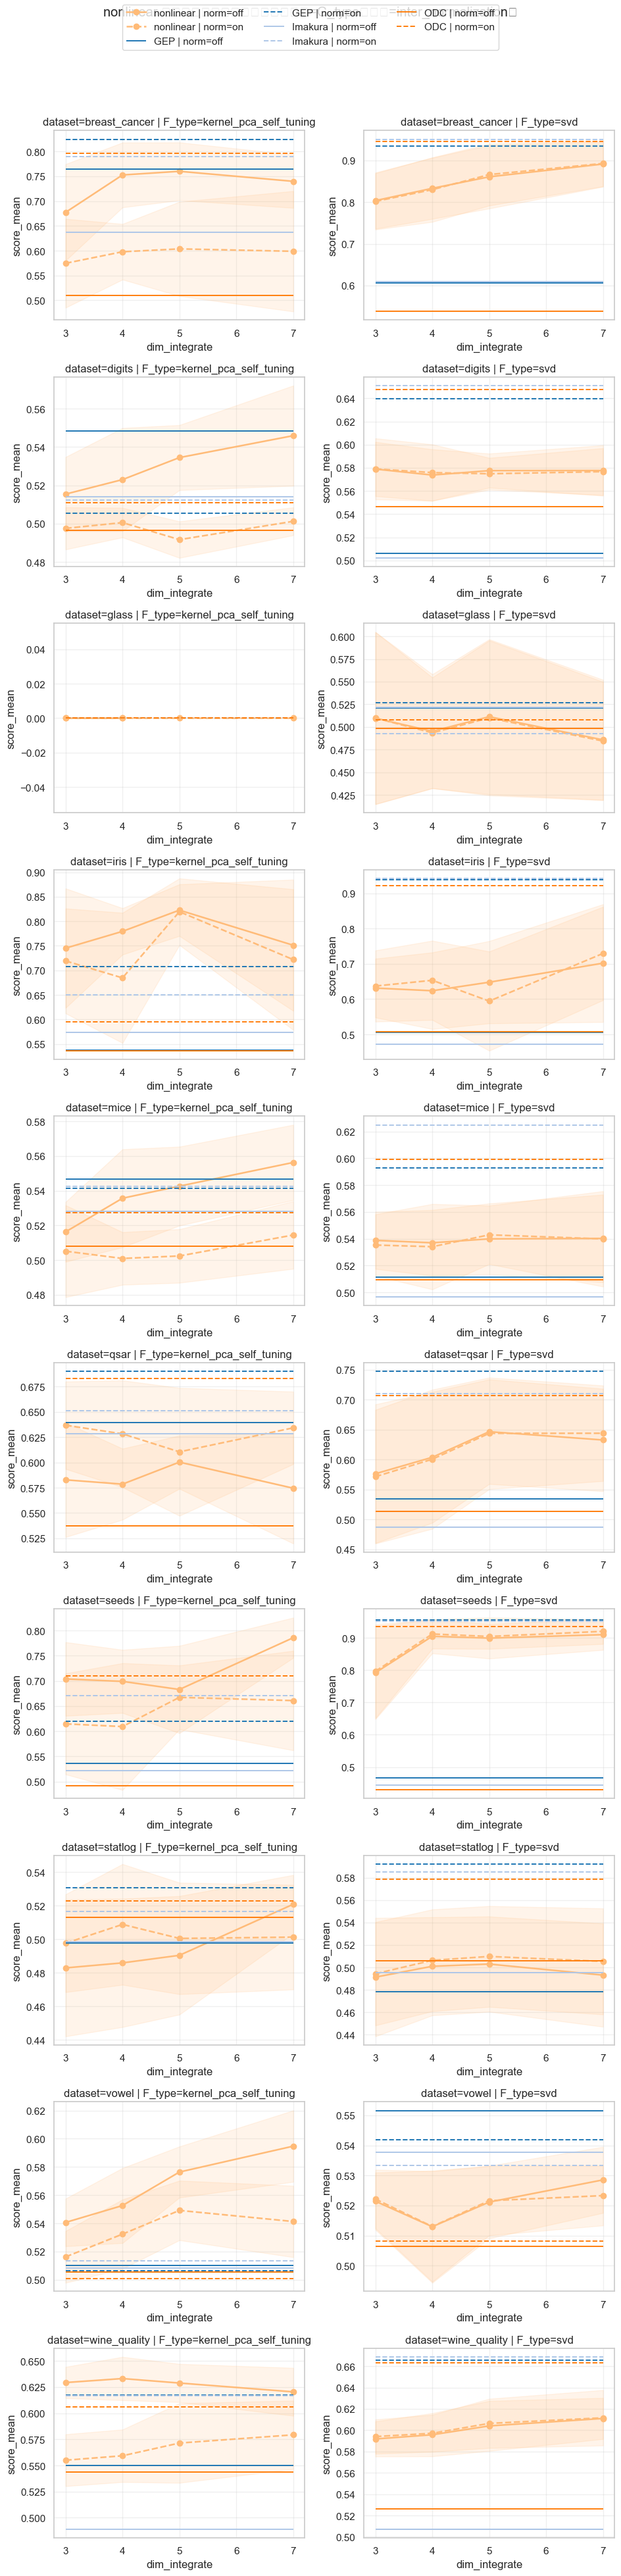

In [15]:
# 描画: dataset × F_type ごとに、G_type=nonlinear は dim_integrate を x に、その他 G_type は各値ごとに横線
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

# 色は G_type ごとに固定
G_types = sorted(agg['G_type'].astype(str).dropna().unique())
_palette = sns.color_palette('tab20', n_colors=max(3, len(G_types)))
color_map = {gt: _palette[i % len(_palette)] for i, gt in enumerate(G_types)}

# 線種: inter_norm_flag False=実線, True=点線
linestyle_map = {False: '-', True: '--'}

# 描画
unique_ds = sorted(agg['dataset'].dropna().unique())
unique_ft = sorted(agg['F_type'].dropna().unique())

nrows = max(1, len(unique_ds))
ncols = max(1, len(unique_ft))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4.8*ncols, 3.8*nrows), sharey=False)
axes = np.array(axes).reshape(nrows, ncols)

for i, ds in enumerate(unique_ds):
    for j, ft in enumerate(unique_ft):
        ax = axes[i, j]
        sub = agg[(agg['dataset'] == ds) & (agg['F_type'] == ft)]
        if sub.empty:
            ax.set_visible(False)
            continue

        # nonlinear を先に描画（色は 'nonlinear' 用）
        sub_nl = sub[sub['G_type'].astype(str).str.lower() == 'nonlinear']
        for flag, df_flag in sub_nl.groupby('inter_norm_flag'):
            df_flag = df_flag.sort_values('dim_integrate')
            ax.plot(df_flag['dim_integrate'], df_flag['score_mean'],
                    label=f"nonlinear | norm={'on' if flag else 'off'}",
                    color=color_map.get('nonlinear', 'C0'), linestyle=linestyle_map[flag], marker='o', linewidth=1.8)
            # 標準偏差の帯
            y = df_flag['score_mean'].to_numpy()
            s = df_flag['score_stdev'].fillna(0).to_numpy()
            x = df_flag['dim_integrate'].to_numpy()
            ax.fill_between(x, y - s, y + s, color=color_map.get('nonlinear', 'C0'), alpha=0.15)

        # x 範囲（others の横線用）
        if not sub_nl.empty:
            x_min, x_max = sub_nl['dim_integrate'].min(), sub_nl['dim_integrate'].max()
        else:
            # nonlinear が無い場合は sub 全体の dim_integrate 範囲
            x_min, x_max = sub['dim_integrate'].min(), sub['dim_integrate'].max()
            if pd.isna(x_min) or pd.isna(x_max):
                x_min, x_max = 0, 1

        # その他 G_type は、G_type×inter_norm_flag×dim_integrate の各値で横線を描画（平均で潰さない）
        sub_other = sub[~sub['G_type'].astype(str).str.lower().eq('nonlinear')]
        if not sub_other.empty:
            for (gt, flag, dimi), df_g in sub_other.groupby(['G_type','inter_norm_flag','dim_integrate'], dropna=False):
                if df_g.empty:
                    continue
                # 個々の値（score_mean）で横線
                y_const = df_g['score_mean'].iloc[0]
                ax.hlines(y_const, x_min, x_max,
                          colors=color_map.get(str(gt), 'C1'), linestyles=linestyle_map[bool(flag)], linewidth=1.4,
                          label=f"{gt} | norm={'on' if flag else 'off'}")

        ax.set_title(f"dataset={ds} | F_type={ft}")
        ax.set_xlabel('dim_integrate')
        ax.set_ylabel('score_mean')
        ax.grid(True, alpha=0.3)

# 凡例（共通、重複排除）
handles, labels = [], []
for ax in axes.ravel():
    if not ax.has_data():
        continue
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)
uniq = dict(zip(labels, handles))
if uniq:
    fig.legend(uniq.values(), uniq.keys(), loc='upper center', ncol=3, frameon=True)
fig.suptitle('nonlinear は曲線、その他は各値で横線（色=G_type、線種=inter_normalization）', y=1.03)
plt.tight_layout()
plt.show()

In [2]:
from sklearn.datasets import fetch_olivetti_faces, fetch_openml
c = fetch_openml("CIFAR_10")

KeyboardInterrupt: 